In [1]:
import myosuite
import gym
import skvideo.io
import numpy as np
import os
import imageio
import tqdm
import time
from IPython.display import HTML
from base64 import b64encode
import matplotlib.pyplot as plt

MyoSuite:> Registering Myo Envs


In [2]:
def show_video(video_path, video_width = 400):
  
  video_file = open(video_path, "r+b").read()

  video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
  return HTML(f"""<video autoplay width={video_width} controls><source src="{video_url}"></video>""")

# Velocity plots

In [3]:
env = gym.make('CenterReachOut-v0')

    MyoSuite: A contact-rich simulation suite for musculoskeletal motor control
        Vittorio Caggiano, Huawei Wang, Guillaume Durandau, Massimo Sartori, Vikash Kumar
        L4DC-2019 | https://sites.google.com/view/myosuite
    


In [ ]:
import pickle
# load policy

# Load your policy
policy_path = "./models/all_reaches/MLP_wo_feedback_same_reward/policies/seed_42/best_policy.pickle" #Change the folder to the policy location
#policy_path = "./models/all_reaches/MLP_wo_feedback_same_reward/policies/seed_42policy_150.pickle"
pi = pickle.load(open(policy_path, "rb"))

In [4]:
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO

model = PPO.load("MLP-w-feedback-w-reward", env=env)
#model = RecurrentPPO.load("RNN-w-feedback-full-reward", env=env)

pygame 2.5.2 (SDL 2.28.3, Python 3.8.18)
Hello from the pygame community. https://www.pygame.org/contribute.html


c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\stable_baselines3\common\vec_env\base_vec_env.py:77: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")
c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://githu

In [ ]:
%matplotlib widget

import os, imageio, pickle
import numpy as np
import gym
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

r_target = 0.02

# ---------------- Appearance ----------------
plt.rcParams.update({
    "font.size": 12,          # overall font size
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.dpi": 120,
    "axes.edgecolor": "black",
})

# ---------------- Helpers ----------------
def pos_key(pos, ndigits=4):
    return tuple(np.round(np.array(pos, dtype=np.float64), ndigits))

def discover_unique_targets(env, want=8, max_trials=5000, atol=1e-4):
    """Reset until we collect `want` unique obj_pos from THIS env."""
    uniq = []
    for _ in range(max_trials):
        env.reset()
        p = np.copy(env.obs_dict['obj_pos'])
        if not any(np.allclose(p, q, atol=atol) for q in uniq):
            uniq.append(p)
            if len(uniq) == want:
                break
    if len(uniq) < want:
        print(f"Warning: only found {len(uniq)} unique targets.")
    return uniq

def wait_for_target(env, target, atol=1e-4, max_tries=3000):
    """Keep resetting until env.obj_pos ~ target."""
    for _ in range(max_tries):
        env.reset()
        if np.allclose(env.obs_dict['obj_pos'], target, atol=atol):
            return True
    return False

# ---------------- Config ----------------
env = gym.make('CenterReachOut-v0')
frames = []

episodes_per_condition = 100 # <- change as needed
steps_per_episode = 13
save_dir = "figures_all_conditions"
os.makedirs(save_dir, exist_ok=True)
os.makedirs("videos", exist_ok=True)

# ---------------- Discover & order 8 targets ----------------
targets = discover_unique_targets(env, want=8)
center = np.mean(np.array(targets)[:, :2], axis=0)
angles = []
for i, p in enumerate(targets):
    dx, dy = p[0]-center[0], p[1]-center[1]
    ang = (np.arctan2(dy, dx) + 2*np.pi) % (2*np.pi)
    angles.append((ang, i))
targets_ordered = [targets[i] for _, i in sorted(angles, key=lambda x: x[0])]

labels = ["Right","Up-right","Up","Up-left","Left","Down-left","Down","Down-right"]

# ---------------- Collect per-condition ----------------
cond_results = []  # list of dicts with label, target, avg_traj, etc.

for idx, target in enumerate(targets_ordered):
    label = labels[idx % len(labels)]

    per_traj, per_vel = [], []

    for ep in range(episodes_per_condition):
        ok = wait_for_target(env, target)
        if not ok:
            print("Failed to match target after many resets:", target)
            break

        # --- NEW: reset RNN state at the start of each episode ---
        lstm_states = None
        episode_start = np.array([True])  # tells the LSTM this is a fresh episode
    
        palm_traj, velocities = [], []
        for step in range(steps_per_episode):
            print(np.copy(env.obs_dict['palm_pos']))
            hand_qvel = np.copy(env.sim.data.qvel[:].copy())
            velocities.append(np.linalg.norm(hand_qvel))

            # render a frame (for combined video)
            frame = env.sim.renderer.render_offscreen(width=400, height=400, camera_id=1)
            frames.append(frame)

            # get observation
            o = env.get_obs()
            
            #action, _ = pi.get_action(o)

            # --- NEW: pass lstm_states and episode_start to predict() ---
            action, lstm_states = model.predict(
                o,
                state=lstm_states,
                episode_start=episode_start,
                deterministic=True,  # or False if you want stochastic rollouts
            )

            # record palm position
            palm_traj.append(np.copy(env.sim.data.site_xpos[env.palm_sid]))

            # step env
            obs, reward, done, info = env.step(action)

            # --- NEW: update episode_start for the *next* step ---
            episode_start = np.array([done], dtype=bool)

            if done:
                # pad trajectory to fixed length for plotting
                while len(palm_traj) < steps_per_episode:
                    palm_traj.append(palm_traj[-1])
                    velocities.append(0.0)
                    frames.append(frames[-1])
                break

        per_traj.append(np.array(palm_traj))
        per_vel.append(np.array(velocities))

    if len(per_traj) == 0:
        continue

    traj_arr = np.array(per_traj)  # (episodes, steps, 3)
    vel_arr  = np.array(per_vel)   # (episodes, steps)

    avg_traj = traj_arr.mean(axis=0)
    std_traj = traj_arr.std(axis=0)
    avg_vel  = vel_arr.mean(axis=0)
    std_vel  = vel_arr.std(axis=0)

    cond_results.append(dict(
        label=label, target=target,
        all_traj=traj_arr, all_vel=vel_arr,
        avg_traj=avg_traj, std_traj=std_traj,
        avg_vel=avg_vel, std_vel=std_vel
    ))

# ---------------- Plot: combined 3D overlay ----------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# remove grids/panes
ax.grid(False)
ax.set_axis_off()  # <- hides axes, ticks, labels, panes

for res in cond_results:
    # plot every trajectory in thick black
    for tr in res["all_traj"]:
        ax.plot(tr[:,0], tr[:,1], tr[:,2], color='black', linewidth=4)

    # black target marker + circle
    t = res["target"]
    ax.scatter(t[0], t[1], t[2], marker='X', s=100, color='black')
    theta = np.linspace(0, 2*np.pi, 200)
    cx = t[0] + r_target*np.cos(theta)
    cy = t[1] + r_target*np.sin(theta)
    cz = np.full_like(theta, t[2])
    ax.plot(cx, cy, cz, linestyle='--', color='black', linewidth=2)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "traj_all_conditions_3d_black.png"), dpi=300, bbox_inches='tight')
plt.show()


# ---------------- Per-condition 2D XY plots ----------------
for i, res in enumerate(cond_results):
    t = res["target"]
    fig2, ax2 = plt.subplots(figsize=(7,6))

    for tr in res["all_traj"]:
        ax2.plot(tr[:,0], tr[:,1], color='black', linewidth=4)

    circ = Circle((t[0], t[1]), r_target, facecolor='none',
                  edgecolor='black', linestyle='--', linewidth=2)
    ax2.add_patch(circ)
    ax2.scatter(t[0], t[1], c='black', marker='X', s=120)

    ax2.set_aspect('equal')
    ax2.set_axis_off()  # <- hides axes and ticks

    out = os.path.join(save_dir, f"traj_{i+1:02d}_{res['label']}_black.png")
    plt.savefig(out, dpi=300, bbox_inches='tight')

# ---------------- Save a single combined video ----------------
video_path = "videos/all_conditions.mp4"
imageio.mimsave(video_path, frames, fps=30)
print("Saved combined video to", video_path)

env.close()

OrderedDict([('reach', array(-5.2769)), ('vel', array(-0.0065)), ('penalty', array(-1.)), ('act', array(-0.0129)), ('sparse', -0.5276916271221971), ('solved', array(0.)), ('done', array(False)), ('dense', -5.2962865512381185)])
[-0.2187 -0.314   1.0752]
[-0.2089 -0.3177  1.0754]
[-0.1754 -0.3218  1.0791]
[-0.1412 -0.3185  1.0674]
[-0.1339 -0.3121  1.0586]
[-0.1374 -0.3082  1.052 ]
[-0.138  -0.3086  1.0517]
[-0.1378 -0.3117  1.0536]
[-0.1372 -0.315   1.0558]
[-0.1366 -0.3171  1.0547]
[-0.1369 -0.3175  1.0543]
[-0.1377 -0.3166  1.0549]
[-0.1385 -0.3156  1.0554]
OrderedDict([('reach', array(-0.111)), ('vel', array(-0.0145)), ('penalty', array(0.)), ('act', array(-0.0252)), ('sparse', -0.011095234285258443), ('solved', array(0.)), ('done', array(True)), ('dense', -0.1506432874900569)])
[-0.2187 -0.314   1.0752]
[-0.2089 -0.3177  1.0754]
[-0.1754 -0.3218  1.0791]
[-0.1412 -0.3185  1.0674]
[-0.1339 -0.3121  1.0586]
[-0.1374 -0.3082  1.052 ]
[-0.138  -0.3086  1.0517]
[-0.1378 -0.3117  1.0536]

KeyboardInterrupt: 

# Get Figures

# 2d Plot

c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\ipywidgets\widgets\widget.py:503: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


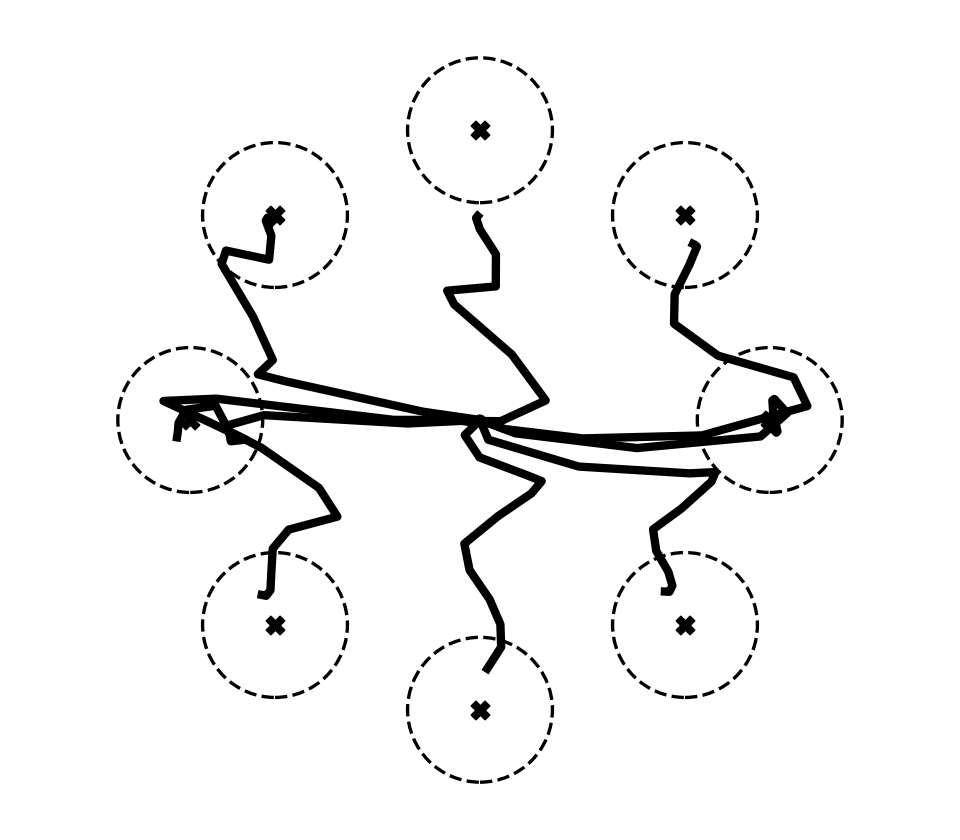

In [36]:
# ---------------- Plot: 2D view of average reaches ----------------
fig_avg2d, ax_avg2d = plt.subplots(figsize=(8, 7))

for i, res in enumerate(cond_results):
    avg_traj = res["avg_traj"]     # shape: (steps, 3)
    t = res["target"]

    # plot the average trajectory
    ax_avg2d.plot(avg_traj[:,0], avg_traj[:,1],
                  color="black", linewidth=5, label=res["label"])

    # mark the final target with X and circle
    circ = Circle((t[0], t[1]), r_target, facecolor='none',
                  edgecolor='black', linestyle='--', linewidth=2)
    ax_avg2d.add_patch(circ)
    ax_avg2d.scatter(t[0], t[1], c='black', marker='X', s=120)

# aesthetics
ax_avg2d.set_aspect('equal')
ax_avg2d.set_axis_off()   # remove ticks/axes

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "avg_reaches_2d.png"),
            dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# ====== 1A: HIGH-QUALITY MUJOCO STILL ======
# Pick a consistent camera (either an XML-named camera or free camera pose).
# Option A: If you have a camera named "isometric" in your MJCF:
# still = env.sim.renderer.render_offscreen(width=2400, height=1800, camera="isometric")

# Option B: Programmatically set a free camera (works in many MyoSuite/MuJoCo setups):
try:
    cam = env.sim.renderer.camera  # some wrappers expose .camera
except AttributeError:
    cam = getattr(env.sim.renderer, "cam", None)

if cam is not None:
    cam.azimuth = 135       # rotate around model
    cam.elevation = -10     # slight downward tilt
    cam.distance = 0.5     # <-- closer (try 0.9–1.2)
    cam.lookat = np.array([
        center[0],          # focus on XY center of targets
        center[1],
        np.mean(np.array(targets)[:,2])  # approx Z center
    ])

# Try enabling MSAA if available
if hasattr(env.sim.renderer, "samples"):
    env.sim.renderer.samples = 8  # 4/8/16 depending on GPU/driver support

# Render a **single** large still for 1a
still_1a = env.sim.renderer.render_offscreen(width=4400, height=1800, camera_id=1)
os.makedirs("figures", exist_ok=True)
imageio.imwrite("figures/1a_mujoco_environment.png", still_1a)
print("Saved: figures/1a_mujoco_environment.png")

Saved: figures/1a_mujoco_environment.png


In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --------------------------- Optional SciPy imports ---------------------------
_HAVE_SCIPY = False
_HAVE_SCIPY_SIGNAL = False
try:
    from scipy.interpolate import UnivariateSpline
    _HAVE_SCIPY = True
except Exception:
    pass

try:
    from scipy.signal import savgol_filter
    _HAVE_SCIPY_SIGNAL = True
except Exception:
    pass

# ================================ CONFIG =====================================
# I/O
# Expect: `save_dir` (str) and `cond_results` (list of dicts) are defined upstream.
# Each dict: {"label": str, "all_vel": np.ndarray[E, T], "avg_vel": ..., "std_vel": ...}
# Only "all_vel" is required; we recompute stats.

VEL_SUBDIR = "velocities"
PNG_DPI = 300
FIGSIZE = (7, 5)

# Data timing
STEP_DT_MS = 20  # each time step = 20 ms
BASELINE_PRE_SAMPLES = 5  # first N samples used for per-episode baseline (e.g., 5 → 100 ms)

# Variability band: one of {"std", "sem", "ci95"}
BAND_STAT = "sem"

# Per-episode smoothing BEFORE averaging (recommended if you need smoothing).
SMOOTH_EPISODES = True
# If SciPy is available, Savitzky–Golay is used; otherwise, a simple moving average.
SAVGOL_WINDOW = 11  # must be odd and <= T
SAVGOL_POLY = 3

MOVAVG_WINDOW = 7    # used only if SciPy.signal isn't available

# Optional display-only smoothing of the mean trace (never smooth variability).
DISPLAY_SPLINE_SMOOTHING = True
SPLINE_K = 3
SPLINE_S = 0  # 0 = exact fit inside segments (keeps segment endpoints)
# Spline segments in INDEX space (inclusive) to avoid edge artifacts at true endpoints.
SPLINE_SEGMENTS = [(5, 40), (245, 350)]  # will be clamped to data length

# Plotting options
LINE_COLOR = "black"
BAND_COLOR = "black"
BAND_ALPHA = 0.25
TITLE_FMT = "{label} — mean ± {band} velocity (n={n})"
XLABEL = "Time (ms)"
YLABEL = "Speed (||q̇||)"
LEGEND_FRAMEON = False

# Summary and per-reach options
AVERAGE_THRESHOLD = 20
SAVE_EACH_REACH = False
SAVE_SUMMARY_WHEN_MANY = True
SUMMARY_EXAMPLES = 6  # faint example traces in summary plot

# Plotting options
LINE_COLOR = "black"
BAND_COLOR = "black"
BAND_ALPHA = 0.25
TITLE_FMT = "{label} — mean ± {band} velocity (n={n})"
XLABEL = "Time (ms)"
YLABEL = "Speed (||q̇||)"
LEGEND_FRAMEON = False

# New: also output non-smoothed mean ± band plots
PLOT_RAW_VERSION = True

# ============================== UTILITIES ====================================
def _time_axis(n_steps, dt_ms=STEP_DT_MS):
    return np.arange(n_steps) * dt_ms  # ms

def _moving_average(x, w):
    if w <= 1:
        return x
    # symmetric causal+acausal via 'same' conv
    kernel = np.ones(w, dtype=float) / float(w)
    return np.convolve(x, kernel, mode="same")

def _smooth_episode(y):
    """Optional per-episode smoothing BEFORE averaging."""
    if not SMOOTH_EPISODES:
        return y
    if _HAVE_SCIPY_SIGNAL and SAVGOL_WINDOW >= 3 and SAVGOL_WINDOW % 2 == 1:
        w = min(SAVGOL_WINDOW, len(y) if len(y) % 2 == 1 else len(y) - 1)
        w = max(w, 3)
        return savgol_filter(y, window_length=w, polyorder=min(SAVGOL_POLY, w - 1))
    # Fallback: simple moving average (keeps endpoints reasonably)
    w = min(MOVAVG_WINDOW, len(y))
    w = max(w, 1)
    if w % 2 == 0:
        w += 1
    return _moving_average(y, w)

def _piecewise_spline_mean(y_mean, segments, k=SPLINE_K, s=SPLINE_S):
    """Display-only smoothing on the mean trace over specified index segments."""
    if not DISPLAY_SPLINE_SMOOTHING or not _HAVE_SCIPY:
        return y_mean

    y = np.asarray(y_mean)
    out = y.copy()
    T = len(y)
    for a, b in segments:
        a = max(0, a)
        b = min(T - 1, b)
        if b <= a:
            continue
        n = b - a + 1
        if n < (k + 1):
            continue
        x = np.arange(a, b + 1)
        spl = UnivariateSpline(x, y[a:b + 1], k=k, s=s)
        out[a:b + 1] = spl(x)
    return out

def _variability_band(proc, stat="sem"):
    """
    proc: (E, T) processed episodes (baseline-corrected, optionally smoothed).
    Returns (center, lower, upper) where center=mean, and lower/upper are mean ± band.
    """
    mean = proc.mean(axis=0)
    std = proc.std(axis=0, ddof=1) if proc.shape[0] > 1 else np.zeros_like(mean)

    if stat.lower() == "std":
        band = std
        band_label = "1 SD"
    elif stat.lower() == "sem":
        band = std / np.sqrt(max(proc.shape[0], 1))
        band_label = "1 SEM"
    elif stat.lower() in ("ci", "ci95", "95ci", "95%ci"):
        sem = std / np.sqrt(max(proc.shape[0], 1))
        band = 1.96 * sem
        band_label = "95% CI"
    else:
        raise ValueError("BAND_STAT must be one of {'std','sem','ci95'}")

    return mean, mean - band, mean + band, band_label

def _ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

# =============================== MAIN ========================================
def plot_velocity_conditions(cond_results, save_dir):
    vel_dir = _ensure_dir(os.path.join(save_dir, VEL_SUBDIR))

    for i, res in enumerate(cond_results):
        label = res["label"]
        vel_arr = np.asarray(res["all_vel"])  # (E, T)
        n_eps, n_steps = vel_arr.shape

        # --- per-episode baseline for BOTH raw and smoothed versions ---
        proc_raw = []     # baseline-corrected, NOT smoothed
        proc_smooth = []  # baseline-corrected, MAY be smoothed

        for ep in range(n_eps):
            y = vel_arr[ep].astype(float).copy()

            # baseline: first BASELINE_PRE_SAMPLES
            base = np.mean(y[:BASELINE_PRE_SAMPLES]) if BASELINE_PRE_SAMPLES > 0 else 0.0
            y_bc = np.clip(y - base, 0.0, None)  # keep speed non-negative

            # store raw (no smoothing)
            proc_raw.append(y_bc)

            # smooth version for the original behavior
            y_sm = _smooth_episode(y_bc)
            proc_smooth.append(y_sm)

        proc_raw = np.vstack(proc_raw) if len(proc_raw) else vel_arr
        proc_smooth = np.vstack(proc_smooth) if len(proc_smooth) else vel_arr

        # --- recompute stats on processed episodes (SMOOTHED for main plot) ---
        mean_raw_s, low_s, high_s, band_label = _variability_band(proc_smooth, BAND_STAT)

        # optional display-only spline on the mean (never touch low/high)
        mean_disp_s = _piecewise_spline_mean(mean_raw_s, SPLINE_SEGMENTS)

        # --- ALSO compute stats for NON-SMOOTHED version ---
        mean_raw_ns, low_ns, high_ns, band_label_ns = _variability_band(proc_raw, BAND_STAT)
        # For the raw version, we usually DON'T spline the mean:
        mean_disp_ns = mean_raw_ns

        # --- time axis ---
        t = _time_axis(n_steps)

        # --------------------------- Figure: mean ± band (SMOOTHED) -----------------------
        fig, ax = plt.subplots(figsize=FIGSIZE)
        ax.plot(t, mean_disp_s, linewidth=3, color=LINE_COLOR, label="mean (smoothed)")
        ax.fill_between(t, low_s, high_s, alpha=BAND_ALPHA, color=BAND_COLOR, label=f"±{band_label}")

        ax.set_title(TITLE_FMT.format(label=label, band=band_label, n=n_eps))
        ax.set_xlabel(XLABEL)
        ax.set_ylabel(YLABEL)
        ax.legend(frameon=LEGEND_FRAMEON)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()

        base = os.path.join(vel_dir, f"vel_meanstd_{i+1:02d}_{label}")
        plt.savefig(base + ".png", dpi=PNG_DPI, bbox_inches="tight")
        plt.savefig(base + ".pdf", bbox_inches="tight")
        plt.close(fig)

        # ---------------------- NEW: Figure: mean ± band (RAW / NON-SMOOTH) --------------
        if PLOT_RAW_VERSION:
            fig_r, ax_r = plt.subplots(figsize=FIGSIZE)
            ax_r.plot(t, mean_disp_ns, linewidth=2.5, color=LINE_COLOR, label="mean (raw)")
            ax_r.fill_between(t, low_ns, high_ns, alpha=BAND_ALPHA, color=BAND_COLOR, label=f"±{band_label_ns}")

            ax_r.set_title(f"{label} — mean ± {band_label_ns} velocity (raw, n={n_eps})")
            ax_r.set_xlabel(XLABEL)
            ax_r.set_ylabel(YLABEL)
            ax_r.legend(frameon=LEGEND_FRAMEON)
            ax_r.spines['top'].set_visible(False)
            ax_r.spines['right'].set_visible(False)
            plt.tight_layout()

            base_raw = os.path.join(vel_dir, f"vel_meanstd_raw_{i+1:02d}_{label}")
            plt.savefig(base_raw + ".png", dpi=PNG_DPI, bbox_inches="tight")
            plt.savefig(base_raw + ".pdf", dpi=PNG_DPI, bbox_inches="tight")
            plt.close(fig_r)

        # ---------------------- Optional: per-reach plots (SMOOTHED) ----------------------
        if SAVE_EACH_REACH:
            each_dir = _ensure_dir(os.path.join(vel_dir, f"each_reach_{i+1:02d}_{label}"))
            for ep in range(n_eps):
                fig_ep, ax_ep = plt.subplots(figsize=(6, 4))
                ax_ep.plot(t, proc_smooth[ep], linewidth=1.8, color=LINE_COLOR)
                ax_ep.set_title(f"{label} — reach #{ep+1}")
                ax_ep.set_xlabel(XLABEL)
                ax_ep.set_ylabel(YLABEL)
                ax_ep.spines['top'].set_visible(False)
                ax_ep.spines['right'].set_visible(False)
                plt.tight_layout()
                plt.savefig(os.path.join(each_dir, f"vel_reach_{ep+1:03d}.png"),
                            dpi=PNG_DPI, bbox_inches="tight")
                plt.close(fig_ep)

        # --------------- Optional: compact summary when many episodes (SMOOTHED) ----------
        if SAVE_SUMMARY_WHEN_MANY and n_eps >= AVERAGE_THRESHOLD:
            fig_sum, ax_sum = plt.subplots(figsize=FIGSIZE)
            # faint examples (smoothed)
            show_k = min(SUMMARY_EXAMPLES, n_eps)
            sample_ids = np.linspace(0, n_eps - 1, show_k, dtype=int)
            for ep in sample_ids:
                ax_sum.plot(t, proc_smooth[ep], linewidth=1.0, color=LINE_COLOR, alpha=0.12)
            # overlay mean ± band (smoothed)
            ax_sum.plot(t, mean_disp_s, linewidth=3, color=LINE_COLOR, label="mean (smoothed)")
            ax_sum.fill_between(t, low_s, high_s, alpha=BAND_ALPHA, color=BAND_COLOR, label=f"±{band_label}")

            ax_sum.set_title(f"{label} — summary (n={n_eps})")
            ax_sum.set_xlabel(XLABEL)
            ax_sum.set_ylabel(YLABEL)
            ax_sum.legend(frameon=LEGEND_FRAMEON)
            ax_sum.spines['top'].set_visible(False)
            ax_sum.spines['right'].set_visible(False)
            plt.tight_layout()

            base = os.path.join(vel_dir, f"vel_summary_{i+1:02d}_{label}")
            plt.savefig(base + ".png", dpi=PNG_DPI, bbox_inches="tight")
            plt.savefig(base + ".pdf", bbox_inches="tight")
            plt.close(fig_sum)

In [39]:
plot_velocity_conditions(cond_results, save_dir)

c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\ipywidgets\widgets\widget.py:503: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)
c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\ipywidgets\widgets\widget.py:503: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)
c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\ipywidgets\widgets\widget.py:503: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be